In [22]:
import os
import sys
import subprocess
try:
   import pyarrow
except ImportError:
   subprocess.check_call([sys.executable, "-m", "pip", "install", "pyarrow", "-q"])
os.environ["JAVA_HOME"] = r"D:\java\openjdk-8u482-b08"
os.environ["HADOOP_HOME"] = r"D:\java\hadoop-3.4.3"
os.environ["SPARK_HOME"] = r"D:\BIGDATA_G16\.venv\Lib\site-packages\pyspark"
os.environ["SPARK_LOCAL_DIRS"] = r"D:\BIGDATA_G16\Spark_Temp"
sys.path.append(r"D:\java\hadoop-3.4.3\bin")
sys.path.append(r"D:\BIGDATA_G16\.venv\Scripts")
from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType, IntegerType, TimestampType
try:
   SparkContext.getOrCreate().stop()
except Exception:
   pass
spark = SparkSession.builder \
   .appName("MetroPT3_MasterNode_Group16_EDA") \
   .master("local[*]") \
   .config("spark.executor.memory", "2g") \
   .config("spark.driver.memory", "2g") \
   .config("spark.local.dir", r"D:\BIGDATA_G16\Spark_Temp") \
   .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
   .getOrCreate()
hdfs_path = "hdfs://10.125.222.18:9000/Group16/MetroPT3(AirCompressor).csv"
df_raw = spark.read.csv(hdfs_path, header=True, inferSchema=False)
analog_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_electric', 'DV_eletric', 'TOWERS', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']
df = df_raw
for c in df.columns:
   c_upper = c.upper()
   if c_upper in [x.upper() for x in analog_cols]:
       df = df.withColumn(c, col(c).cast(DoubleType()))
   elif c_upper in [x.upper() for x in digital_cols]:
       df = df.withColumn(c, col(c).cast(IntegerType()))
   elif c_upper == "TIMESTAMP":
       df = df.withColumn(c, col(c).cast(TimestampType()))
df_clean = df
df.printSchema()
print("----------------------------------------------------------------")
print(f"-> Tổng số dòng dữ liệu: {df.count():,} dòng.")
print("----------------------------------------------------------------")

root
 |-- _c0: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- TP2: double (nullable = true)
 |-- TP3: double (nullable = true)
 |-- H1: double (nullable = true)
 |-- DV_pressure: double (nullable = true)
 |-- Reservoirs: double (nullable = true)
 |-- Oil_temperature: double (nullable = true)
 |-- Motor_current: double (nullable = true)
 |-- COMP: integer (nullable = true)
 |-- DV_eletric: integer (nullable = true)
 |-- Towers: integer (nullable = true)
 |-- MPG: integer (nullable = true)
 |-- LPS: integer (nullable = true)
 |-- Pressure_switch: integer (nullable = true)
 |-- Oil_level: integer (nullable = true)
 |-- Caudal_impulses: integer (nullable = true)

----------------------------------------------------------------
-> Tổng số dòng dữ liệu: 1,516,948 dòng.
----------------------------------------------------------------


In [23]:
print("--- KIỂM TRA SCHEMA CỦA TẬP DỮ LIỆU SƠ CẤP ---")
df.printSchema()

--- KIỂM TRA SCHEMA CỦA TẬP DỮ LIỆU SƠ CẤP ---
root
 |-- _c0: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- TP2: double (nullable = true)
 |-- TP3: double (nullable = true)
 |-- H1: double (nullable = true)
 |-- DV_pressure: double (nullable = true)
 |-- Reservoirs: double (nullable = true)
 |-- Oil_temperature: double (nullable = true)
 |-- Motor_current: double (nullable = true)
 |-- COMP: integer (nullable = true)
 |-- DV_eletric: integer (nullable = true)
 |-- Towers: integer (nullable = true)
 |-- MPG: integer (nullable = true)
 |-- LPS: integer (nullable = true)
 |-- Pressure_switch: integer (nullable = true)
 |-- Oil_level: integer (nullable = true)
 |-- Caudal_impulses: integer (nullable = true)



In [24]:
analog_cols = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
raw_summary = df.select(analog_cols).summary("min", "max", "mean", "stddev", "25%", "50%", "75%").toPandas()
summary_analog_df = raw_summary.set_index("summary").transpose().reset_index()
summary_analog_df.columns = ["Feature", "Min", "Max", "Mean", "Stddev", "Q1", "Median", "Q3"]
print("\n--- BẢNG KẾT QUẢ THỐNG KÊ MÔ TẢ ĐẦY ĐỦ CÁC CẢM BIẾN ANALOG ---")
summary_analog_df


--- BẢNG KẾT QUẢ THỐNG KÊ MÔ TẢ ĐẦY ĐỦ CÁC CẢM BIẾN ANALOG ---


,Feature,Min,Max,Mean,Stddev,Q1,Median,Q3
0,TP2,-0.032,10.676,1.3678259663489785,3.2509296807037504,-0.0139999999999993,-0.0120000000000004,-0.009999999999998
1,TP3,0.7300000000000004,10.302,8.98461070122439,0.6390950863089495,8.492,8.96,9.492
2,H1,-0.0360000000000013,10.288,7.5681549004980555,3.333199565289423,8.254,8.784,9.374
3,DV_pressure,-0.032,9.844,0.05595618966494397,0.3824015460354255,-0.0219999999999984,-0.0199999999999995,-0.0180000000000006
4,Reservoirs,0.7119999999999997,10.3,8.985233443730726,0.6383070418596223,8.494,8.96,9.492
5,Oil_temperature,15.400000000000006,89.05000000000001,62.64418173860267,6.516261089444954,57.775000000000006,62.7,67.25000000000001
6,Motor_current,0.0199999999999995,9.295,2.0501708034835966,2.3020534138867563,0.04,0.0449999999999999,3.807500000000001


In [25]:
from pyspark.sql.functions import col, count, when, round
digital_cols = ["COMP", "DV_eletric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]
total_count = df.count()
exprs = []
for c in digital_cols:
    display_name = "DV_electric" if c == "DV_eletric" else c
    exprs.append(round((count(when(col(c) == '0.0', 1)) / total_count) * 100, 1).alias(f"{display_name}_%_0"))
    exprs.append(round((count(when(col(c) == '1.0', 1)) / total_count) * 100, 1).alias(f"{display_name}_%_1"))
summary_raw = df.select(exprs).collect()[0].asDict()
rows = []
for c in digital_cols:
    display_name = "DV_electric" if c == "DV_eletric" else c
    p0 = f"{summary_raw[f'{display_name}_%_0']}%"
    p1 = f"{summary_raw[f'{display_name}_%_1']}%"
    rows.append({
        "Tín hiệu": display_name,
        "% = 0": p0,
        "% = 1": p1
    })
import pandas as pd
summary_digital_df = pd.DataFrame(rows)
print("\n--- BẢNG KẾT QUẢ THỐNG KÊ TẦN SUẤT TÍN HIỆU DIGITAL TỪ HDFS ---")
summary_digital_df


--- BẢNG KẾT QUẢ THỐNG KÊ TẦN SUẤT TÍN HIỆU DIGITAL TỪ HDFS ---


,Tín hiệu,% = 0,% = 1
0,COMP,16.3%,83.7%
1,DV_electric,83.9%,16.1%
2,Towers,8.0%,92.0%
3,MPG,16.7%,83.3%
4,LPS,99.7%,0.3%
5,Pressure_switch,0.9%,99.1%
6,Oil_level,9.6%,90.4%
7,Caudal_impulses,6.3%,93.7%


In [26]:
from pyspark.sql.functions import col, count, when, isnan
import pandas as pd
null_exprs = []
for c in df.columns:
    if c == "timestamp":
        null_exprs.append(count(when(col(c).isNull(), 1)).alias(c))
    else:
        null_exprs.append(count(when(col(c).isNull() | isnan(col(c).cast("double")), 1)).alias(c))
null_counts_dict = df.select(null_exprs).collect()[0].asDict()
missing_rows = []
for col_name, missing_count in null_counts_dict.items():
    display_name = "DV_electric" if col_name == "DV_eletric" else col_name
    percentage = (missing_count / 1516948) * 100

    missing_rows.append({
        "Thuộc tính": display_name,
        "Số dòng khuyết thiếu (Null/NaN)": missing_count,
        "Tỷ lệ (%)": f"{percentage:.3f}%",
    })
df_missing_summary = pd.DataFrame(missing_rows)

print("\n--- BẢNG KẾT QUẢ-")
df_missing_summary


--- BẢNG KẾT QUẢ-


,Thuộc tính,Số dòng khuyết thiếu (Null/NaN),Tỷ lệ (%)
0,_c0,0,0.000%
1,timestamp,0,0.000%
2,TP2,0,0.000%
3,TP3,0,0.000%
4,H1,0,0.000%
5,DV_pressure,0,0.000%
6,Reservoirs,0,0.000%
7,Oil_temperature,0,0.000%
8,Motor_current,0,0.000%
9,COMP,0,0.000%


In [27]:
total_raw_rows = df.count()
distinct_raw_rows = df.dropDuplicates().count()
duplicate_exist = total_raw_rows - distinct_raw_rows

print(f"-> Tổng số lượng bản ghi hiện có trong tập dữ liệu gốc: {total_raw_rows:,} dòng.")
print(f"-> Số lượng bản ghi định danh duy nhất (Distinct):     {distinct_raw_rows:,} dòng.")
print(f"-> Số lượng bản ghi trùng lặp tồn tại trong dữ liệu gốc: {duplicate_exist} dòng.")

-> Tổng số lượng bản ghi hiện có trong tập dữ liệu gốc: 1,516,948 dòng.
-> Số lượng bản ghi định danh duy nhất (Distinct):     1,516,948 dòng.
-> Số lượng bản ghi trùng lặp tồn tại trong dữ liệu gốc: 0 dòng.


In [28]:
from pyspark.sql.functions import col
import pandas as pd
import builtins

# 1. Định nghĩa hàm quét phân tán để đếm số lượng
def get_raw_outlier_pct(df_spark, column_name, q1, q3):
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Bộ lọc đếm số dòng nằm ngoài biên độ IQR của dữ liệu gốc
    outliers_count = df_spark.filter((col(column_name).cast("double") < lower_bound) |
                                     (col(column_name).cast("double") > upper_bound)).count()
    outlier_pct = (outliers_count / 1516948) * 100
    return builtins.round(outlier_pct, 1)

# 2. Khai báo các thông số Q1, Q3 thu thập từ ma trận thống kê mô tả sơ cấp
analog_specs = [
    {"Feature": "TP2", "Q1": -0.014, "Q3": -0.010, "Giải thích": "Trạng thái máy tắt / khởi động / Pre-Failure"},
    {"Feature": "TP3", "Q1": 8.492, "Q3": 9.492, "Giải thích": "Biến động áp suất panel khi chuyển trạng thái"},
    {"Feature": "H1", "Q1": 8.254, "Q3": 9.374, "Giải thích": "Đột biến khi bộ lọc cyclonic xả — sự kiện bình thường"},
    {"Feature": "DV_pressure", "Q1": -0.022, "Q3": -0.018, "Giải thích": "Tháp sấy xả ẩm — xảy ra định kỳ theo chu kỳ"},
    {"Feature": "Reservoirs", "Q1": 8.494, "Q3": 9.492, "Giải thích": "Áp suất bình tích khí chính biến động chu kỳ chạy tải"},
    {"Feature": "Oil_temperature", "Q1": 57.775, "Q3": 67.250, "Giải thích": "Máy vừa khởi động (thấp) hoặc quá nhiệt (cao)"},
    {"Feature": "Motor_current", "Q1": 0.040, "Q3": 3.808, "Giải thích": "Trạng thái tắt (~0A) hoặc vượt tải (>9A)"}
]

# 3. Tiến hành truy vấn song song và cấu trúc hóa bảng kết quả thống kê
outlier_rows = []
for spec in analog_specs:
    f_name = spec["Feature"]
    q1_val = spec["Q1"]
    q3_val = spec["Q3"]
    iqr_val = builtins.round(q3_val - q1_val, 3)

    pct_outlier = get_raw_outlier_pct(df, f_name, q1_val, q3_val)

    outlier_rows.append({
        "Feature": f_name,
        "Q1": q1_val,
        "Q3": q3_val,
        "IQR": iqr_val,
        "% Outlier gốc": f"~{pct_outlier}%",
        "Ý nghĩa kỹ thuật": spec["Giải thích"]
    })

df_outlier_summary = pd.DataFrame(outlier_rows)

print("\n--- BẢNG TỔNG HỢP ---")
df_outlier_summary


--- BẢNG TỔNG HỢP ---


,Feature,Q1,Q3,IQR,% Outlier gốc,Ý nghĩa kỹ thuật
0,TP2,-0.014,-0.010,0.004,~17.8%,Trạng thái máy tắt / khởi động / Pre-Failure
1,TP3,8.492,9.492,1.000,~0.3%,Biến động áp suất panel khi chuyển trạng thái
2,H1,8.254,9.374,1.120,~15.9%,Đột biến khi bộ lọc cyclonic xả — sự kiện bình...
3,DV_pressure,-0.022,-0.018,0.004,~5.6%,Tháp sấy xả ẩm — xảy ra định kỳ theo chu kỳ
4,Reservoirs,8.494,9.492,0.998,~0.3%,Áp suất bình tích khí chính biến động chu kỳ c...
5,Oil_temperature,57.775,67.250,9.475,~0.3%,Máy vừa khởi động (thấp) hoặc quá nhiệt (cao)
6,Motor_current,0.040,3.808,3.768,~0.0%,Trạng thái tắt (~0A) hoặc vượt tải (>9A)


In [29]:
# Import các hàm xử lý Spark cần thiết
from pyspark.sql.functions import col, to_timestamp, hour, month, dayofweek, avg, count
from pyspark.sql.types import IntegerType

# Định nghĩa danh sách thuộc tính dựa trên schema dữ liệu gốc của nhóm
analog_cols = ["TP2", "TP3", "H1", "DV_pressure", "Reservoirs", "Oil_temperature", "Motor_current"]
digital_cols = ["COMP", "DV_eletric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]

In [30]:
# =========================================================================
# Ô CODE TỔNG HỢP: TIỀN XỬ LÝ (3.4) VÀ THỐNG KÊ CHUỖI THỜI GIAN (3.5)
# =========================================================================

from pyspark.sql.functions import col, to_timestamp, hour, month, dayofweek, avg, count
from pyspark.sql.types import IntegerType
import pandas as pd
import builtins

# -------------------------------------------------------------------------
# MỤC 3.4: TIỀN XỬ LÝ DỮ LIỆU
# -------------------------------------------------------------------------
df_clean = df.withColumn("timestamp", to_timestamp(col("timestamp"), "yyyy-MM-dd HH:mm:ss"))
df_clean = df_clean.withColumnRenamed("DV_eletric", "DV_electric")

digital_cols_clean = ["COMP", "DV_electric", "Towers", "MPG", "LPS", "Pressure_switch", "Oil_level", "Caudal_impulses"]
for c in digital_cols_clean:
    df_clean = df_clean.withColumn(c, col(c).cast(IntegerType()))

df_clean = df_clean \
    .withColumn("hour", hour(col("timestamp"))) \
    .withColumn("month", month(col("timestamp"))) \
    .withColumn("dow", dayofweek(col("timestamp")))

In [31]:
HDFS_CLEAN_FOR_SQL = "hdfs://10.125.222.18:9000/user/bigdata/cleaned/metropt3_clean_for_sql"
df_clean.write.mode("overwrite").parquet(HDFS_CLEAN_FOR_SQL)

In [32]:
from pyspark.sql.functions import col
df_master = df_clean.withColumn("Pressure_Delta", col("Reservoirs") - col("TP2"))
from pyspark import StorageLevel
df_master = df_master.persist(StorageLevel.MEMORY_AND_DISK)
df_master.select("TP2", "Reservoirs", "Pressure_Delta").show(5)
print(f"-> Dataset hiện tại có {df_master.count():,} dòng và {len(df_master.columns)} cột.")

+-------------------+----------+-----------------+
|                TP2|Reservoirs|   Pressure_Delta|
+-------------------+----------+-----------------+
|-0.0120000000000004|     9.358|9.370000000000001|
|-0.0139999999999993|     9.348|            9.362|
|-0.0120000000000004|     9.338|             9.35|
|-0.0120000000000004|     9.328|             9.34|
|-0.0120000000000004|     9.318|             9.33|
+-------------------+----------+-----------------+
only showing top 5 rows

-> Dataset hiện tại có 1,516,948 dòng và 21 cột.


In [33]:
from pyspark.sql.functions import variance
from pyspark.sql.types import TimestampType, StringType
import pandas as pd
numeric_cols = [f.name for f in df_master.schema.fields
                if not isinstance(f.dataType, (TimestampType, StringType))]
variance_exprs = [variance(col(c)).alias(c) for c in numeric_cols]
variance_result = df_master.agg(*variance_exprs).collect()[0].asDict()
variance_pdf = pd.DataFrame(list(variance_result.items()), columns=["Feature", "Variance"])
variance_pdf = variance_pdf.sort_values(by="Variance", ascending=True)
print("--- BẢNG PHƯƠNG SAI CÁC ĐẶC TRƯNG ---")
print(variance_pdf.to_string(index=False))

--- BẢNG PHƯƠNG SAI CÁC ĐẶC TRƯNG ---
        Feature  Variance
            LPS  0.003408
Pressure_switch  0.008490
Caudal_impulses  0.058938
         Towers  0.073727
      Oil_level  0.086658
    DV_electric  0.134815
           COMP  0.136460
            MPG  0.139335
    DV_pressure  0.146231
     Reservoirs  0.407436
            TP3  0.408443
            dow  3.880615
          month  4.056395
  Motor_current  5.299450
            TP2 10.568544
 Pressure_Delta 11.027454
             H1 11.110219
Oil_temperature 42.461659
           hour 43.652590


In [34]:
df_master = df_master.drop("LPS", "Pressure_switch")
df_master = df_master.persist(StorageLevel.MEMORY_AND_DISK)
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
cols_to_check = ["TP3", "Reservoirs", "TP2", "Motor_current", "Oil_temperature", "Pressure_Delta"]
assembler_corr = VectorAssembler(inputCols=cols_to_check, outputCol="corr_features")
df_corr = assembler_corr.transform(df_master).select("corr_features")
corr_matrix = Correlation.corr(df_corr, "corr_features").head()[0]
corr_pdf = pd.DataFrame(corr_matrix.toArray(), columns=cols_to_check, index=cols_to_check)
print("--- MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN ANALOG ---")
print(corr_pdf.to_string())

--- MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN ANALOG ---
                      TP3  Reservoirs       TP2  Motor_current  Oil_temperature  Pressure_Delta
TP3              1.000000    0.999993 -0.011161       0.413756         0.401616        0.203142
Reservoirs       0.999993    1.000000 -0.012403       0.412691         0.401647        0.204359
TP2             -0.011161   -0.012403  1.000000       0.697480         0.250710       -0.981355
Motor_current    0.413756    0.412691  0.697480       1.000000         0.528739       -0.603487
Oil_temperature  0.401616    0.401647  0.250710       0.528739         1.000000       -0.168234
Pressure_Delta   0.203142    0.204359 -0.981355      -0.603487        -0.168234        1.000000


In [35]:
df_master = df_master.drop("LPS", "Pressure_switch", "TP3", "TP2")
df_master = df_master.persist(StorageLevel.MEMORY_AND_DISK)
print(f"Tổng số lượng đặc trưng: {len(df_master.columns)}")
print("Danh sách đặc trưng:", df_master.columns)

Tổng số lượng đặc trưng: 17
Danh sách đặc trưng: ['_c0', 'timestamp', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_electric', 'Towers', 'MPG', 'Oil_level', 'Caudal_impulses', 'hour', 'month', 'dow', 'Pressure_Delta']


In [36]:
from pyspark.ml.feature import PCA, VectorAssembler, StandardScaler
physical_features = [
    'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current',
    'COMP', 'DV_electric', 'Towers', 'MPG', 'Oil_level', 'Caudal_impulses', 'Pressure_Delta'
]
assembler = VectorAssembler(inputCols=physical_features, outputCol="features_vec")
df_vec = assembler.transform(df_master.drop('_c0', 'timestamp', 'hour', 'month', 'dow'))
scaler = StandardScaler(inputCol="features_vec", outputCol="features_scaled", withStd=True, withMean=True)
scaler_model = scaler.fit(df_vec)
df_scaled = scaler_model.transform(df_vec)
pca = PCA(k=6, inputCol="features_scaled", outputCol="pca_features")
pca_model = pca.fit(df_scaled)
import pandas as pd
loadings = pca_model.pc.toArray()
df_loadings = pd.DataFrame(loadings, index=physical_features, columns=[f"PC{i+1}" for i in range(6)])
print(df_loadings.abs().sort_values(by="PC1", ascending=False))

                      PC1       PC2       PC3       PC4       PC5       PC6
COMP             0.396725  0.055795  0.038049  0.040627  0.075099  0.075264
MPG              0.395260  0.038420  0.083330  0.040342  0.063078  0.104201
DV_electric      0.392106  0.041706  0.005835  0.044980  0.083645  0.171454
H1               0.389559  0.153208  0.000535  0.016277  0.067829  0.135629
Pressure_Delta   0.386438  0.140272  0.007150  0.014164  0.059472  0.144258
Motor_current    0.298056  0.397668  0.091696  0.118214  0.142525  0.104983
Towers           0.285620  0.040054  0.169499  0.038405  0.052071  0.932502
DV_pressure      0.206099  0.003192  0.330316  0.352130  0.669190  0.091376
Oil_temperature  0.131530  0.566817  0.138474  0.235935  0.296641  0.011629
Reservoirs       0.028976  0.651347  0.094369  0.252190  0.272765  0.086374
Caudal_impulses  0.020750  0.127181  0.673839  0.460765  0.544975  0.112018
Oil_level        0.008800  0.170469  0.602608  0.723339  0.212163  0.076156


In [37]:
import numpy as np
import pandas as pd
from pyspark.ml.feature import PCA
pca_objective = PCA(k=12, inputCol="features_scaled", outputCol="pca_features_obj")
pca_model_obj = pca_objective.fit(df_scaled)
explained_variance = pca_model_obj.explainedVariance
cum_variance = np.cumsum(explained_variance)
df_variance = pd.DataFrame({
    "Component": range(1, 13),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cum_variance
})
print("--- BẢNG PHƯƠNG SAI TÍCH LŨY (PCA) ---")
print(df_variance.to_string(index=False))

--- BẢNG PHƯƠNG SAI TÍCH LŨY (PCA) ---
 Component  Explained Variance  Cumulative Variance
         1            0.509622             0.509622
         2            0.145008             0.654630
         3            0.090966             0.745596
         4            0.079281             0.824877
         5            0.074018             0.898895
         6            0.044118             0.943014
         7            0.031416             0.974430
         8            0.015923             0.990353
         9            0.005253             0.995606
        10            0.002985             0.998591
        11            0.001055             0.999646
        12            0.000354             1.000000


In [38]:
import numpy as np
import pandas as pd
df_loadings['Score'] = np.sqrt((df_loadings**2).sum(axis=1))
print("--- ĐIỂM ĐÓNG GÓP CỦA CÁC ĐẶC TRƯNG (PCA MAGNITUDE) ---")
print(df_loadings[['Score']].sort_values(by='Score', ascending=True))

--- ĐIỂM ĐÓNG GÓP CỦA CÁC ĐẶC TRƯNG (PCA MAGNITUDE) ---
                    Score
COMP             0.418219
MPG              0.425576
Pressure_Delta   0.440011
DV_electric      0.440382
H1               0.445522
Motor_current    0.548357
Oil_temperature  0.708203
Reservoirs       0.761222
DV_pressure      0.855427
Oil_level        0.983008
Towers           0.992804
Caudal_impulses  0.996250


In [39]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark import StorageLevel
import pandas as pd
final_features = [
    'Caudal_impulses', 'Towers', 'Oil_level', 'DV_pressure',
    'Reservoirs', 'Oil_temperature', 'Motor_current'
]
assembler_final = VectorAssembler(inputCols=final_features, outputCol="features_final")
scaler_final = StandardScaler(inputCol="features_final", outputCol="features_scaled_final", withStd=True, withMean=True)
pipeline_final = Pipeline(stages=[assembler_final, scaler_final])
model_final = pipeline_final.fit(df_master)
df_final_kmeans = model_final.transform(df_master).select("features_scaled_final").persist(StorageLevel.MEMORY_AND_DISK)
k_values = range(2, 9)
silhouette_scores = []
print(f"{'K':<5} | {'Silhouette Score':<20}")
print("-" * 30)
for k in k_values:
    kmeans = KMeans(featuresCol="features_scaled_final", k=k, seed=42)
    model = kmeans.fit(df_final_kmeans)
    predictions = model.transform(df_final_kmeans)
    evaluator = ClusteringEvaluator(
        featuresCol="features_scaled_final",
        metricName="silhouette",
        distanceMeasure="squaredEuclidean"
    )
    score = evaluator.evaluate(predictions)
    silhouette_scores.append(score)
    print(f"{k:<5} | {score:.4f}")
df_results = pd.DataFrame({"K": list(k_values), "Silhouette": silhouette_scores})

K     | Silhouette Score    
------------------------------
2     | 0.6287
3     | 0.4556
4     | 0.5410
5     | 0.6173
6     | 0.6781
7     | 0.5308
8     | 0.5355



--- BẢNG TỌA ĐỘ TÂM CỤM (CENTROIDS) ---
            Caudal_impulses  Towers  Oil_level  DV_pressure  Reservoirs  Oil_temperature  Motor_current
Cluster_ID                                                                                             
0                     0.259   0.293      0.326       -0.199      -0.488           -0.587         -0.838
1                     0.247  -1.485      0.313        5.175      -0.935            1.732          1.512
2                    -3.860  -0.337     -0.272       -0.175       0.203            0.264          0.196
3                     0.259   0.294     -3.071       -0.193       0.088            0.463         -0.062
4                     0.259   0.295      0.326       -0.158       0.840            0.559          0.904
5                     0.259  -3.388     -0.018        0.002       0.066            0.238          1.631
Đang xử lý dữ liệu đồ họa...


D:\BIGDATA_G16\.venv\Lib\site-packages\pyspark\sql\pandas\conversion.py:117: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unsupported type in conversion to Arrow: VectorUDT()
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


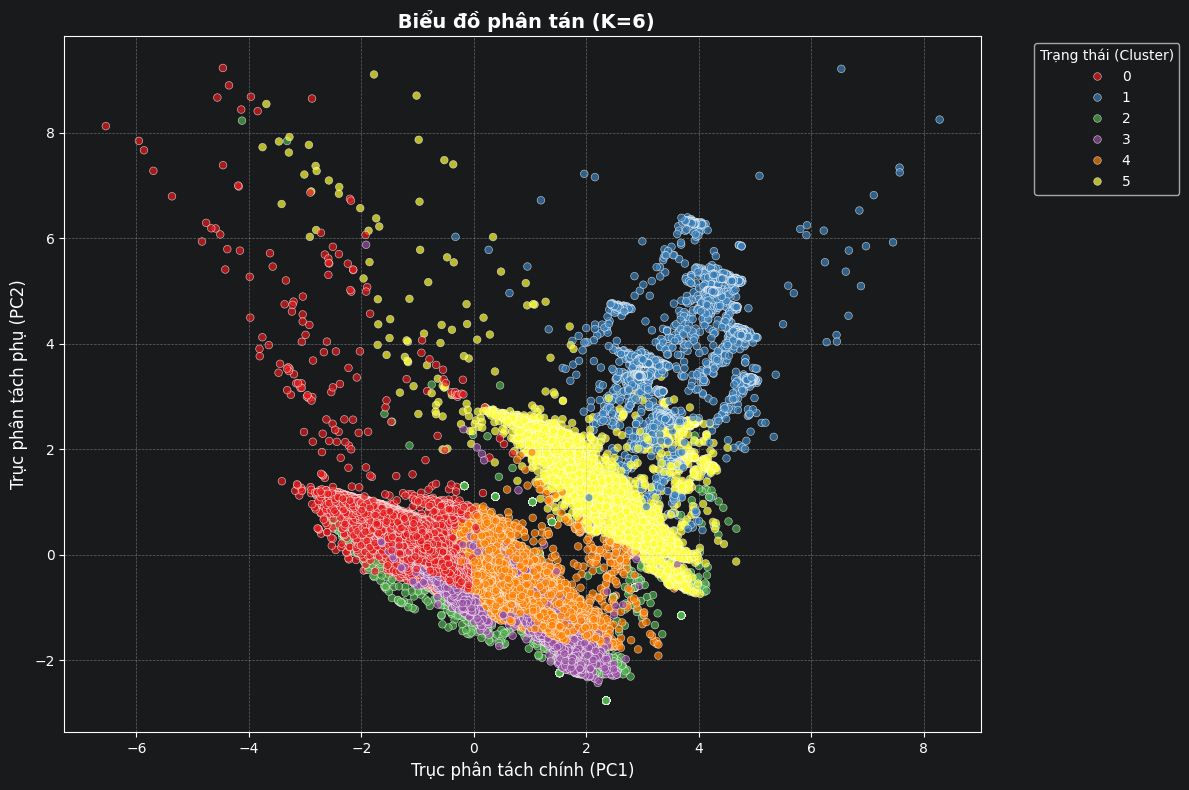

In [40]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
kmeans = KMeans(featuresCol="features_scaled_final", k=6, seed=42)
best_model = kmeans.fit(df_final_kmeans)
predictions = best_model.transform(df_final_kmeans)
centers = best_model.clusterCenters()
df_centroids = pd.DataFrame(centers, columns=final_features)
df_centroids.index.name = "Cluster_ID"
print("\n--- BẢNG TỌA ĐỘ TÂM CỤM (CENTROIDS) ---")
print(df_centroids.round(3).to_string())
pca_viz = PCA(k=6, inputCol="features_scaled_final", outputCol="pca_2d")
predictions_2d = pca_viz.fit(predictions).transform(predictions)
print("Đang xử lý dữ liệu đồ họa...")
df_viz = predictions_2d.select("pca_2d", "prediction").sample(fraction=0.05, seed=42).toPandas()
df_viz['PC1'] = df_viz['pca_2d'].apply(lambda x: x[0])
df_viz['PC2'] = df_viz['pca_2d'].apply(lambda x: x[1])
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_viz,
    x='PC1',
    y='PC2',
    hue='prediction',
    palette='Set1',
    alpha=0.7,
    s=30
)
plt.title(" Biểu đồ phân tán (K=6)", fontsize=14, fontweight='bold')
plt.xlabel("Trục phân tách chính (PC1)", fontsize=12)
plt.ylabel("Trục phân tách phụ (PC2)", fontsize=12)
plt.legend(title="Trạng thái (Cluster)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Biểu đồ phân tán.png", dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()


--- BẢNG PHÂN BỔ THỜI GIAN VẬN HÀNH ---
 Cluster_ID  Số lượng (điểm dữ liệu)  Tỷ lệ (%)
          0                   732661      48.30
          1                    49332       3.25
          2                    95232       6.28
          3                   120272       7.93
          4                   438545      28.91
          5                    80906       5.33


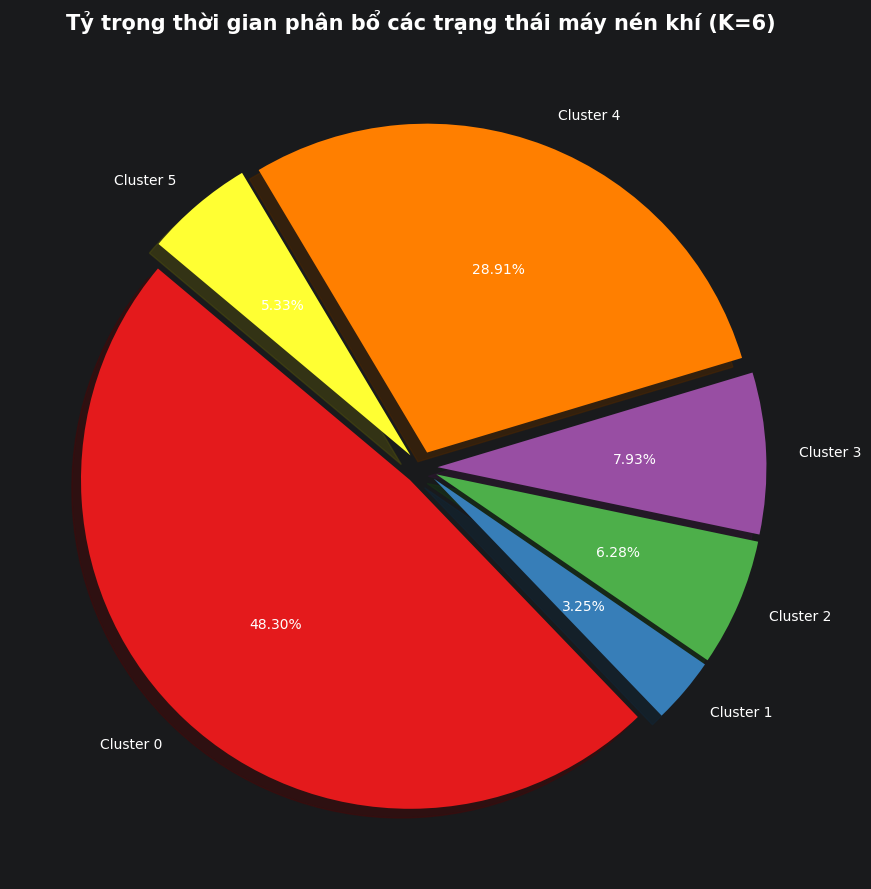

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
cluster_counts = predictions.groupBy("prediction").count().toPandas()
total_points = cluster_counts['count'].sum()
cluster_counts['Tỷ lệ (%)'] = (cluster_counts['count'] / total_points) * 100
cluster_counts = cluster_counts.sort_values(by="prediction").reset_index(drop=True)
cluster_counts.rename(columns={"prediction": "Cluster_ID", "count": "Số lượng (điểm dữ liệu)"}, inplace=True)
print("\n--- BẢNG PHÂN BỔ THỜI GIAN VẬN HÀNH ---")
print(cluster_counts.round(2).to_string(index=False))
plt.figure(figsize=(9, 9))
explode = [0.05] * len(cluster_counts)
plt.pie(
    cluster_counts['Tỷ lệ (%)'],
    labels=[f"Cluster {i}" for i in cluster_counts['Cluster_ID']],
    autopct='%1.2f%%',
    startangle=140,
    colors=sns.color_palette("Set1", n_colors=len(cluster_counts)),
    explode=explode,
    shadow=True
)
plt.title("Tỷ trọng thời gian phân bổ các trạng thái máy nén khí (K=6)", fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("Tỷ lệ cluster.png", dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()

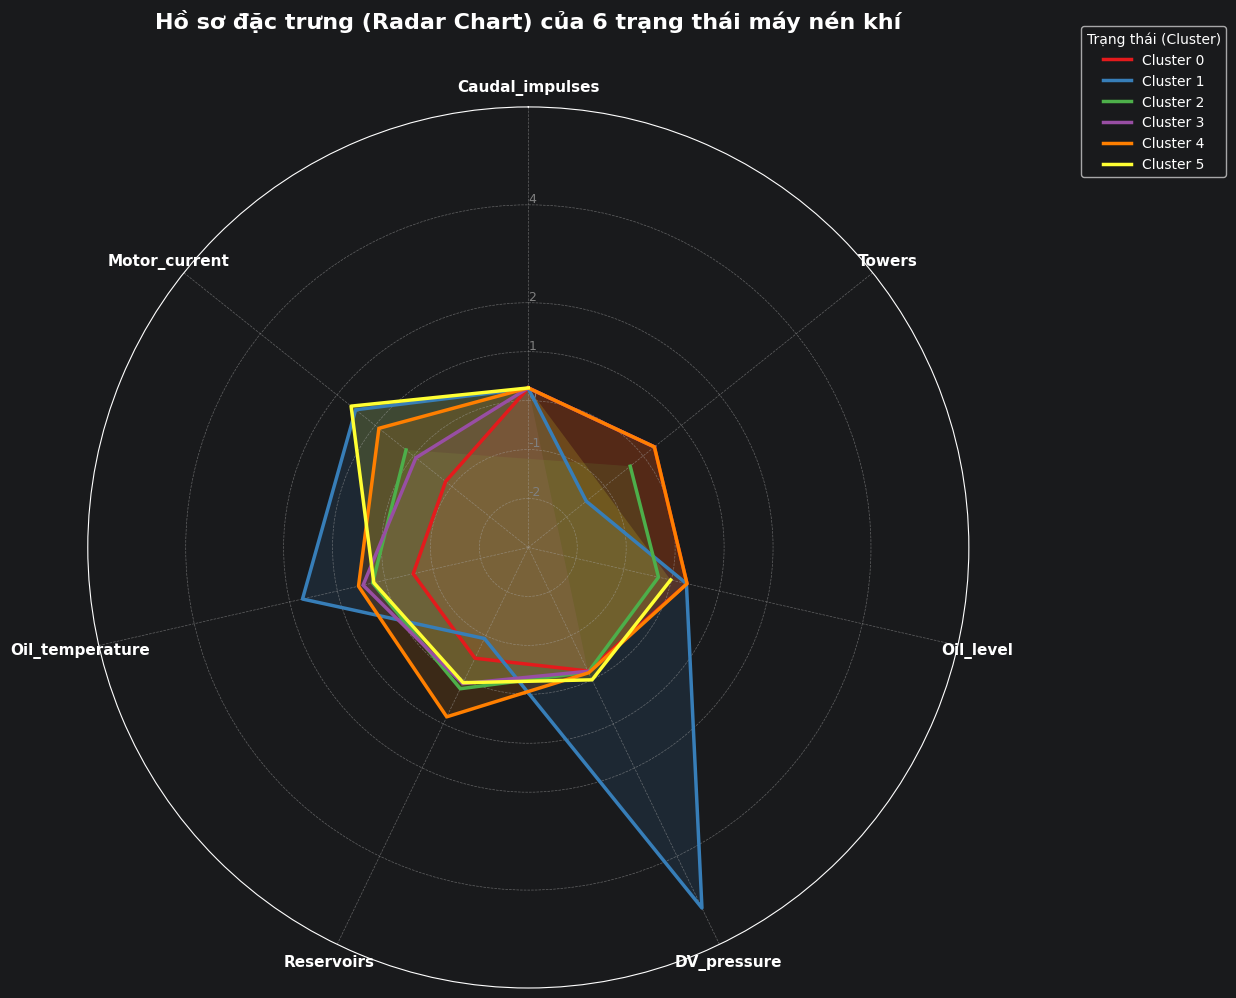

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
categories = final_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
plt.figure(figsize=(12, 10))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, size=11, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([-2, -1, 0, 1, 2, 4], ["-2", "-1", "0", "1", "2", "4"], color="grey", size=9)
plt.ylim(-3, 6)
colors = sns.color_palette("Set1", n_colors=6)
for i in range(len(df_centroids)):
    values = df_centroids.iloc[i].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=f"Cluster {i}")
    ax.fill(angles, values, color=colors[i], alpha=0.15)
plt.title("Hồ sơ đặc trưng (Radar Chart) của 6 trạng thái máy nén khí", size=16, fontweight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="Trạng thái (Cluster)", fontsize=10)
plt.grid(color='#AAAAAA', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("radar_chart_clusters.png", dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()